<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana9/Semana9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# SEMANA 9 - LABORATÓRIO: ESTATÍSTICA AVANÇADA COM VISUALIZAÇÃO
# Dataset: Preço de Carros Usados (MSRP)
# Atualizado para Pandas 3.0+ e Seaborn v0.14+
# ==============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Configuração visual global
sns.set_theme(style="whitegrid", palette="muted")

print("A carregar e higienizar a base de Carros (MSRP)...")
url_github = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
df_bruto = pd.read_csv(url_github)

# Limpeza expressa
df_bruto['Engine HP'] = df_bruto['Engine HP'].fillna(df_bruto['Engine HP'].median())
df = df_bruto.dropna().copy()
print(f"Base pronta com {df.shape[0]} registros!")

A carregar e higienizar a base de Carros (MSRP)...
Base pronta com 8136 registros!


## Dia 1


DIA 1: DETEÇÃO DE ANOMALIAS (Z-SCORE E IQR)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Z_Score_MSRP,É_Outlier
469,Ferrari,458 Italia,2014,premium unleaded (required),597.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,17,13,2774,288000,3.394706,True
472,Ferrari,458 Italia,2015,premium unleaded (required),562.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,17,13,2774,263553,3.045904,True
473,Ferrari,458 Italia,2015,premium unleaded (required),597.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,17,13,2774,291744,3.448124,True
611,Maybach,57,2010,premium unleaded (required),543.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury",Large,Sedan,16,10,67,366000,4.507585,True
612,Maybach,57,2010,premium unleaded (required),631.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,High-Performance",Large,Sedan,16,10,67,455500,5.784541,True
613,Maybach,57,2010,premium unleaded (required),604.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,High-Performance",Large,Sedan,16,10,67,405500,5.071158,True
614,Maybach,57,2011,premium unleaded (required),543.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury",Large,Sedan,16,10,67,372500,4.600324,True
615,Maybach,57,2011,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,High-Performance",Large,Sedan,16,10,67,412000,5.163897,True
616,Maybach,57,2012,premium unleaded (required),543.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury",Large,Sedan,16,10,67,379050,4.693778,True
617,Maybach,57,2012,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Sedan,16,10,67,418950,5.263058,True


O Z-Score encontrou 149 carros com preços absurdos (>3 Desvios Padrão)!
Exemplo Extra: Se usássemos a regra do IQR, qualquer carro acima de $83137.50 seria outlier.


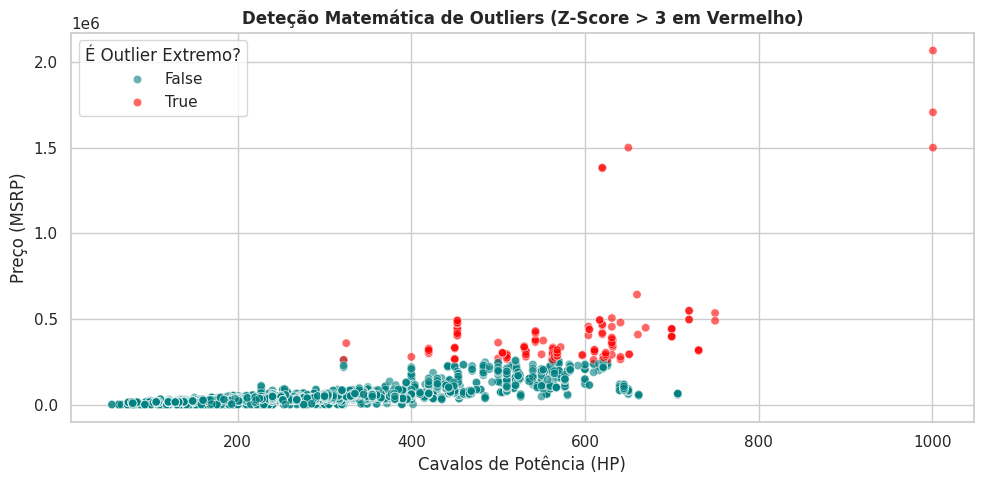

In [2]:
# ==================== DIA 1: A MATEMÁTICA DO CAOS ====================
print("\n" + "="*50)
print("DIA 1: DETEÇÃO DE ANOMALIAS (Z-SCORE E IQR)")
print("="*50)

# Calculando Z-Score
df['Z_Score_MSRP'] = np.abs(stats.zscore(df['MSRP']))
df['É_Outlier'] = df['Z_Score_MSRP'] > 3
display(df[df['É_Outlier'] == True].head(20))
print(f"O Z-Score encontrou {df['É_Outlier'].sum()} carros com preços absurdos (>3 Desvios Padrão)!")

# EXEMPLO EXTRA: Limite usando IQR (Interquartile Range) - Outra técnica famosa no mercado
Q1 = df['MSRP'].quantile(0.25)
Q3 = df['MSRP'].quantile(0.75)
IQR = Q3 - Q1
limite_superior_iqr = Q3 + 1.5 * IQR
print(f"Exemplo Extra: Se usássemos a regra do IQR, qualquer carro acima de ${limite_superior_iqr:.2f} seria outlier.")

# --- GRÁFICO 1: Visualizando os Outliers do Z-Score ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x='Engine HP',
    y='MSRP',
    hue='É_Outlier',
    palette={False: 'teal', True: 'red'},
    alpha=0.6
)
plt.title("Deteção Matemática de Outliers (Z-Score > 3 em Vermelho)", fontweight='bold')
plt.xlabel("Cavalos de Potência (HP)")
plt.ylabel("Preço (MSRP)")
plt.legend(title="É Outlier Extremo?")
plt.tight_layout()
plt.show()

# Filtrando a base para os próximos passos
df_limpo = df[df['É_Outlier'] == False].copy()

## Dia 2


DIA 2: AVALIANDO RELACIONAMENTOS (O PONTO CEGO)


,MSRP,Engine HP,Year,highway MPG
0,46135,335.0,2011,26
1,40650,300.0,2011,28
2,36350,300.0,2011,28
3,29450,230.0,2011,28
4,34500,230.0,2011,28


                 MSRP  Engine HP      Year  highway MPG
MSRP         1.000000   0.770629  0.280470    -0.214382
Engine HP    0.770629   1.000000  0.266249    -0.399614
Year         0.280470   0.266249  1.000000     0.200238
highway MPG -0.214382  -0.399614  0.200238     1.000000
                 MSRP  Engine HP      Year  highway MPG
MSRP         1.000000   0.810831  0.352481    -0.322470
Engine HP    0.810831   1.000000  0.207198    -0.582199
Year         0.352481   0.207198  1.000000     0.290228
highway MPG -0.322470  -0.582199  0.290228     1.000000
Diferença Ano vs Preço -> Pearson: 0.28 | Spearman: 0.35


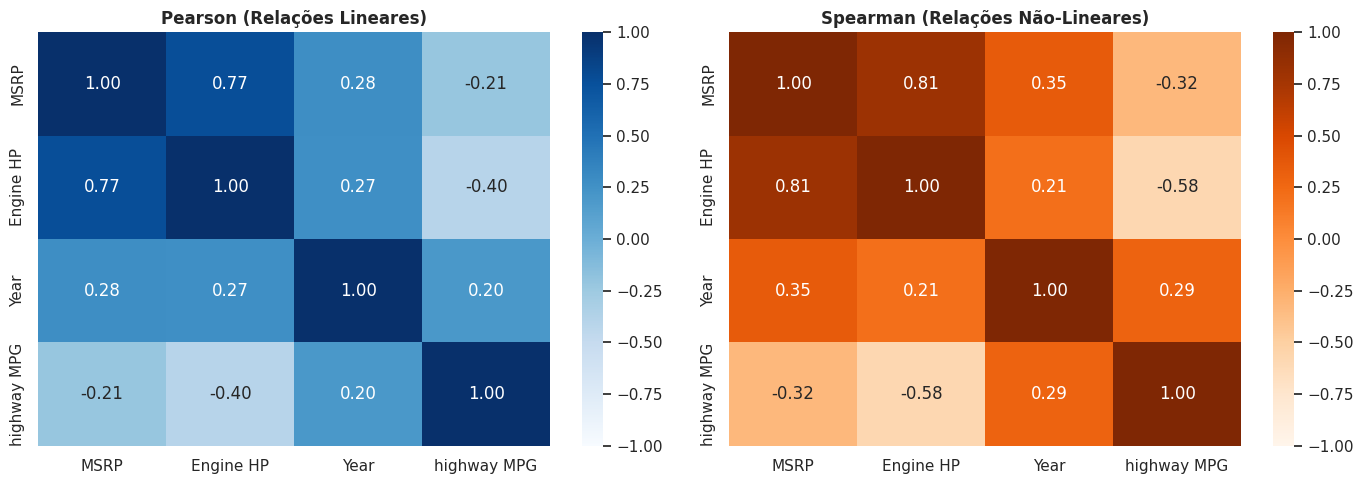

In [4]:
# ==================== DIA 2: PEARSON vs SPEARMAN ====================
print("\n" + "="*50)
print("DIA 2: AVALIANDO RELACIONAMENTOS (O PONTO CEGO)")
print("="*50)

colunas_alvo = ['MSRP', 'Engine HP', 'Year', 'highway MPG']
df_numerico = df_limpo[colunas_alvo]

display(df_numerico.head())

pearson_corr = df_numerico.corr(method='pearson')
spearman_corr = df_numerico.corr(method='spearman')

print(pearson_corr)
print(spearman_corr)
print(f"Diferença Ano vs Preço -> Pearson: {pearson_corr.loc['Year', 'MSRP']:.2f} | Spearman: {spearman_corr.loc['Year', 'MSRP']:.2f}")

# --- GRÁFICO 2: Comparativo de Matrizes de Correlação ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pearson_corr, annot=True, cmap='Blues', fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Pearson (Relações Lineares)", fontweight='bold')

sns.heatmap(spearman_corr, annot=True, cmap='Oranges', fmt=".2f", ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Spearman (Relações Não-Lineares)", fontweight='bold')

plt.tight_layout()
plt.show()

## Dia 3


DIA 3: TESTES DE HIPÓTESES E AVALIAÇÃO DE IA
Teste de Hipóteses (Automático vs Manual): P-Value = 0.00000
Conclusão: Diferença de preços é ESTATISTICAMENTE VERDADEIRA.


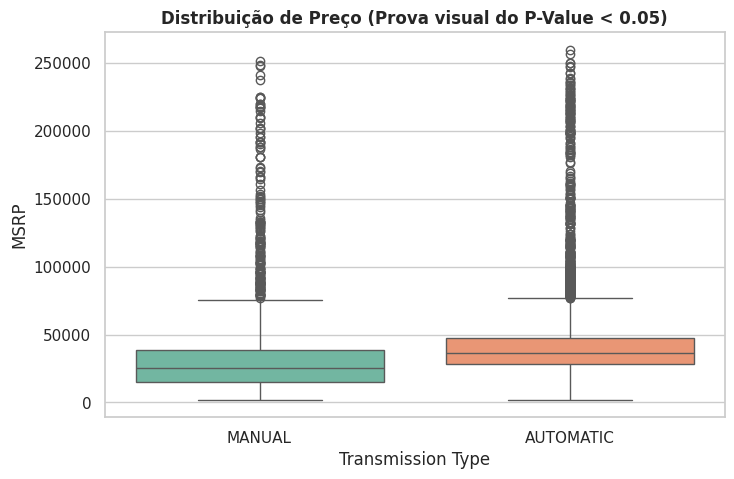

,Engine HP,Year,highway MPG,Engine Cylinders
count,7987.000000,7987.000000,7987.000000,7987.000000
mean,268.721297,2012.093903,27.131213,5.651434
std,107.098106,6.340489,8.931652,1.766539
min,55.000000,1990.000000,12.000000,0.000000
25%,190.000000,2010.000000,23.000000,4.000000
50%,260.000000,2015.000000,26.000000,6.000000
75%,317.000000,2016.000000,30.000000,6.000000
max,707.000000,2017.000000,354.000000,12.000000



R-Quadrado (R²): 0.63 (O modelo explica 62.8% dos preços usando 4 variáveis!)


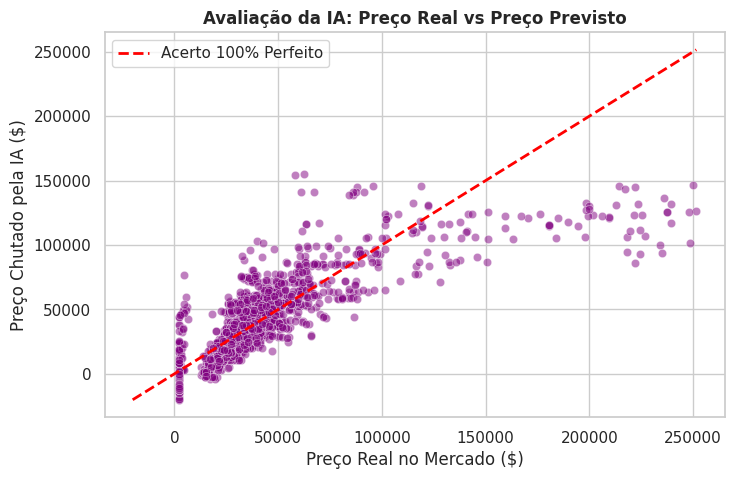

In [8]:
# ==================== DIA 3: PROVA DOS NOVE E ERRO DO MODELO ====================
print("\n" + "="*50)
print("DIA 3: TESTES DE HIPÓTESES E AVALIAÇÃO DE IA")
print("="*50)

# 1. Teste de Hipóteses
precos_auto = df_limpo[df_limpo['Transmission Type'] == 'AUTOMATIC']['MSRP']
precos_manual = df_limpo[df_limpo['Transmission Type'] == 'MANUAL']['MSRP']

estatistica_t, p_value = stats.ttest_ind(precos_auto, precos_manual, equal_var=False)

print(f"Teste de Hipóteses (Automático vs Manual): P-Value = {p_value:.5f}")
if p_value < 0.05:
    print("Conclusão: Diferença de preços é ESTATISTICAMENTE VERDADEIRA.")

# --- GRÁFICO 3: A prova visual do Teste de Hipóteses ---
plt.figure(figsize=(8, 5))
df_filtro_transmissao = df_limpo[df_limpo['Transmission Type'].isin(['AUTOMATIC', 'MANUAL'])]
sns.boxplot(data=df_filtro_transmissao, x='Transmission Type', y='MSRP', hue='Transmission Type', palette='Set2')
plt.title(f"Distribuição de Preço (Prova visual do P-Value < 0.05)", fontweight='bold')
plt.show()

# 2. IA e Regressão
y = df_limpo['MSRP']
# EXEMPLO EXTRA: Adicionando mais colunas (Features) para o modelo ficar mais inteligente
X = df_limpo[['Engine HP', 'Year', 'highway MPG', 'Engine Cylinders']]

display(X.describe())

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.15, random_state=42)

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)

r2 = r2_score(y_teste, previsoes)
print(f"\nR-Quadrado (R²): {r2:.2f} (O modelo explica {r2*100:.1f}% dos preços usando 4 variáveis!)")

# --- GRÁFICO 4: O Erro da Máquina (Previsto vs Real) ---
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_teste, y=previsoes, color='purple', alpha=0.5)

# Linha de perfeição (Onde as previsões seriam 100% iguais à realidade)
min_val = min(y_teste.min(), previsoes.min())
max_val = max(y_teste.max(), previsoes.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Acerto 100% Perfeito')

plt.title("Avaliação da IA: Preço Real vs Preço Previsto", fontweight='bold')
plt.xlabel("Preço Real no Mercado ($)")
plt.ylabel("Preço Chutado pela IA ($)")
plt.legend()
plt.show()